
Cricket Match Win Predictor :

ML project with Pandas operations, statistics, graphs, 4 ML models, accuracy, confusion matrix and new-match prediction.

Educational synthetic dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, classification_report


## 1. Load and Inspect Dataset

In [2]:
df=pd.read_csv('cricket_match_dataset_full.csv')
print(df) ;print("\n")
print('HEAD'); display(df.head()) ;print("\n")
print('TAIL'); display(df.tail()) ;print("\n")
print('SHAPE:',df.shape) ;print("\n")
print('COLUMNS:',df.columns.tolist()) ;print("\n")
print('DTYPES:'); print(df.dtypes) ;print("\n")
df.info()
print('DESCRIBE:'); display(df.describe()) ;print("\n")


           Team1         Team2    TossWinner TossDecision  Team1Score  \
0          India     Australia         India          Bat         185   
1      Australia         India     Australia        Field         160   
2        England         India         India        Field         172   
3          India       England         India          Bat         195   
4       Pakistan     Australia      Pakistan        Field         148   
5      Australia       England     Australia          Bat         178   
6        England         India       England        Field         165   
7          India  South Africa         India          Bat         201   
8   South Africa         India  South Africa        Field         154   
9    New Zealand      Pakistan   New Zealand          Bat         181   
10         India   New Zealand         India        Field         192   
11     Australia         India     Australia          Bat         170   
12      Pakistan       England      Pakistan       

,Team1,Team2,TossWinner,TossDecision,Team1Score,Team2Score,Overs,Wickets,Winner
0,India,Australia,India,Bat,185,170,20,6,Team1
1,Australia,India,Australia,Field,160,175,20,7,Team2
2,England,India,India,Field,172,160,20,5,Team1
3,India,England,India,Bat,195,180,20,4,Team1
4,Pakistan,Australia,Pakistan,Field,148,155,20,8,Team1




TAIL


,Team1,Team2,TossWinner,TossDecision,Team1Score,Team2Score,Overs,Wickets,Winner
25,New Zealand,Australia,New Zealand,Bat,186,172,20,5,Team1
26,India,England,India,Field,203,190,20,3,Team1
27,Pakistan,South Africa,Pakistan,Bat,147,160,20,9,Team2
28,Australia,India,Australia,Field,179,170,20,6,Team1
29,South Africa,Pakistan,South Africa,Bat,161,150,20,8,Team1




SHAPE: (30, 9)


COLUMNS: ['Team1', 'Team2', 'TossWinner', 'TossDecision', 'Team1Score', 'Team2Score', 'Overs', 'Wickets', 'Winner']


DTYPES:
Team1             str
Team2             str
TossWinner        str
TossDecision      str
Team1Score      int64
Team2Score      int64
Overs           int64
Wickets         int64
Winner            str
dtype: object


<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Team1         30 non-null     str  
 1   Team2         30 non-null     str  
 2   TossWinner    30 non-null     str  
 3   TossDecision  30 non-null     str  
 4   Team1Score    30 non-null     int64
 5   Team2Score    30 non-null     int64
 6   Overs         30 non-null     int64
 7   Wickets       30 non-null     int64
 8   Winner        30 non-null     str  
dtypes: int64(4), str(5)
memory usage: 3.2 KB
DESCRIBE:


,Team1Score,Team2Score,Overs,Wickets
count,30.000000,30.000000,30.0,30.000000
mean,173.333333,167.433333,20.0,5.933333
std,18.268747,11.150022,0.0,1.659525
min,145.000000,149.000000,20.0,3.000000
25%,158.500000,160.000000,20.0,5.000000
50%,173.500000,169.000000,20.0,6.000000
75%,187.500000,174.250000,20.0,7.000000
max,205.000000,190.000000,20.0,9.000000


## 2. Data Cleaning and Pandas Operations

In [3]:
print('Missing values:\n',df.isnull().sum()) ;print("\n")
print('Duplicate rows:',df.duplicated().sum());print("\n")
df=df.drop_duplicates()
print('After duplicates:',df.shape);print("\n")
print('Winner counts:\n',df['Winner'].value_counts());print("\n")
print('Unique Team1:',df['Team1'].unique());print("\n")
print('Number of Team1 values:',df['Team1'].nunique());print("\n")
print('Mean:',df['Team1Score'].mean());print("\n")
print('Median:',df['Team1Score'].median());print("\n")
print('Mode:',df['Team1Score'].mode()[0]);print("\n")
print('Sum:',df['Team1Score'].sum());print("\n")
print('Min:',df['Team1Score'].min());print("\n")
print('Max:',df['Team1Score'].max());print("\n")
print('Std:',df['Team1Score'].std());print("\n")
print('Variance:',df['Team1Score'].var());print("\n")
print('SORTED:'); display(df.sort_values('Team1Score',ascending=False).head());print("\n")
print('FILTER >180:'); display(df[df['Team1Score']>180]);print("\n")
print('CORRELATION:'); display(df[['Team1Score','Team2Score','Wickets','Overs']].corr());print("\n")


Missing values:
 Team1           0
Team2           0
TossWinner      0
TossDecision    0
Team1Score      0
Team2Score      0
Overs           0
Wickets         0
Winner          0
dtype: int64


Duplicate rows: 0


After duplicates: (30, 9)


Winner counts:
 Winner
Team1    22
Team2     8
Name: count, dtype: int64


Unique Team1: <ArrowStringArray>
[       'India',    'Australia',      'England',     'Pakistan',
 'South Africa',  'New Zealand',    'Sri Lanka']
Length: 7, dtype: str


Number of Team1 values: 7


Mean: 173.33333333333334


Median: 173.5


Mode: 145


Sum: 5200


Min: 145


Max: 205


Std: 18.26874725964486


Variance: 333.74712643678157


SORTED:


,Team1,Team2,TossWinner,TossDecision,Team1Score,Team2Score,Overs,Wickets,Winner
14,India,Pakistan,India,Field,205,190,20,3,Team1
26,India,England,India,Field,203,190,20,3,Team1
7,India,South Africa,India,Bat,201,178,20,3,Team1
18,India,Australia,India,Field,198,182,20,4,Team1
3,India,England,India,Bat,195,180,20,4,Team1




FILTER >180:


,Team1,Team2,TossWinner,TossDecision,Team1Score,Team2Score,Overs,Wickets,Winner
0,India,Australia,India,Bat,185,170,20,6,Team1
3,India,England,India,Bat,195,180,20,4,Team1
7,India,South Africa,India,Bat,201,178,20,3,Team1
9,New Zealand,Pakistan,New Zealand,Bat,181,170,20,5,Team1
10,India,New Zealand,India,Field,192,180,20,4,Team1
13,England,Australia,England,Bat,188,170,20,5,Team1
14,India,Pakistan,India,Field,205,190,20,3,Team1
18,India,Australia,India,Field,198,182,20,4,Team1
22,India,Sri Lanka,India,Field,190,175,20,5,Team1
25,New Zealand,Australia,New Zealand,Bat,186,172,20,5,Team1




CORRELATION:


,Team1Score,Team2Score,Wickets,Overs
Team1Score,1.000000,0.862618,-0.914841,NaN
Team2Score,0.862618,1.000000,-0.831395,NaN
Wickets,-0.914841,-0.831395,1.000000,NaN
Overs,NaN,NaN,NaN,NaN


## 3. Graphs

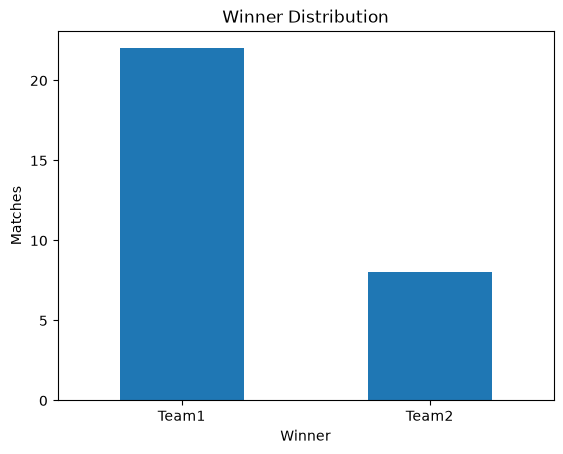

In [4]:
df['Winner'].value_counts().plot(kind='bar'); plt.title('Winner Distribution'); plt.xlabel('Winner'); plt.ylabel('Matches'); plt.xticks(rotation=0); plt.show()


## 4. Machine Learning Preprocessing

In [5]:
X=df.drop('Winner',axis=1).copy()
y=df['Winner'].map({'Team1':1,'Team2':0})
encoders={}
for col in ['Team1','Team2','TossWinner','TossDecision']:
    encoders[col]=LabelEncoder()
    X[col]=encoders[col].fit_transform(X[col])
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
print('Train:',X_train.shape,'Test:',X_test.shape)


Train: (22, 8) Test: (8, 8)


## 5. Train 4 ML Models

In [6]:
models={'Logistic Regression':make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000)),'KNN':make_pipeline(StandardScaler(),KNeighborsClassifier(n_neighbors=5)),'Decision Tree':DecisionTreeClassifier(max_depth=4,random_state=42),'Random Forest':RandomForestClassifier(n_estimators=100,random_state=42)}
results={}; predictions={}
for name,model in models.items():
    model.fit(X_train,y_train); predictions[name]=model.predict(X_test); results[name]=accuracy_score(y_test,predictions[name])
for n,a in results.items(): print(n,round(a*100,2),'%')


Logistic Regression 62.5 %
KNN 75.0 %
Decision Tree 75.0 %
Random Forest 87.5 %


## 6. Accuracy Comparison

,Model,Accuracy
0,Logistic Regression,62.5
1,KNN,75.0
2,Decision Tree,75.0
3,Random Forest,87.5


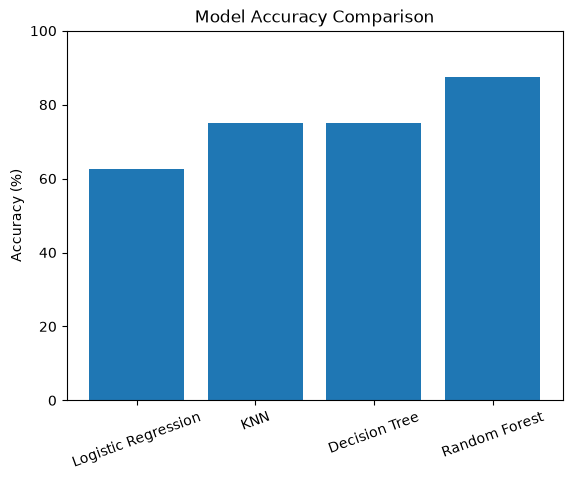

In [7]:
accuracy_df=pd.DataFrame({'Model':list(results.keys()),'Accuracy':[round(v*100,2) for v in results.values()]}); display(accuracy_df)
plt.bar(accuracy_df['Model'],accuracy_df['Accuracy']); plt.ylabel('Accuracy (%)'); plt.title('Model Accuracy Comparison'); plt.ylim(0,100); plt.xticks(rotation=20); plt.show()


## 7. Confusion Matrix + Precision + Recall + F1

Selected model: Random Forest
[[1 1]
 [0 6]]


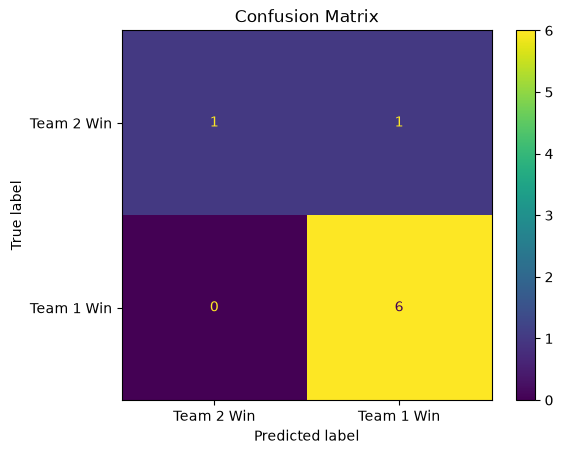

Precision: 0.857
Recall: 1.0
F1: 0.923
              precision    recall  f1-score   support

  Team 2 Win       1.00      0.50      0.67         2
  Team 1 Win       0.86      1.00      0.92         6

    accuracy                           0.88         8
   macro avg       0.93      0.75      0.79         8
weighted avg       0.89      0.88      0.86         8



In [8]:
best_name=max(results,key=results.get); best_model=models[best_name]; pred=predictions[best_name]
print('Selected model:',best_name)
cm=confusion_matrix(y_test,pred); print(cm)
ConfusionMatrixDisplay(cm,display_labels=['Team 2 Win','Team 1 Win']).plot(); plt.title('Confusion Matrix'); plt.show()
print('Precision:',round(precision_score(y_test,pred,zero_division=0),3))
print('Recall:',round(recall_score(y_test,pred,zero_division=0),3))
print('F1:',round(f1_score(y_test,pred,zero_division=0),3))
print(classification_report(y_test,pred,target_names=['Team 2 Win','Team 1 Win'],zero_division=0))


## 8. Decision Tree and Feature Importance

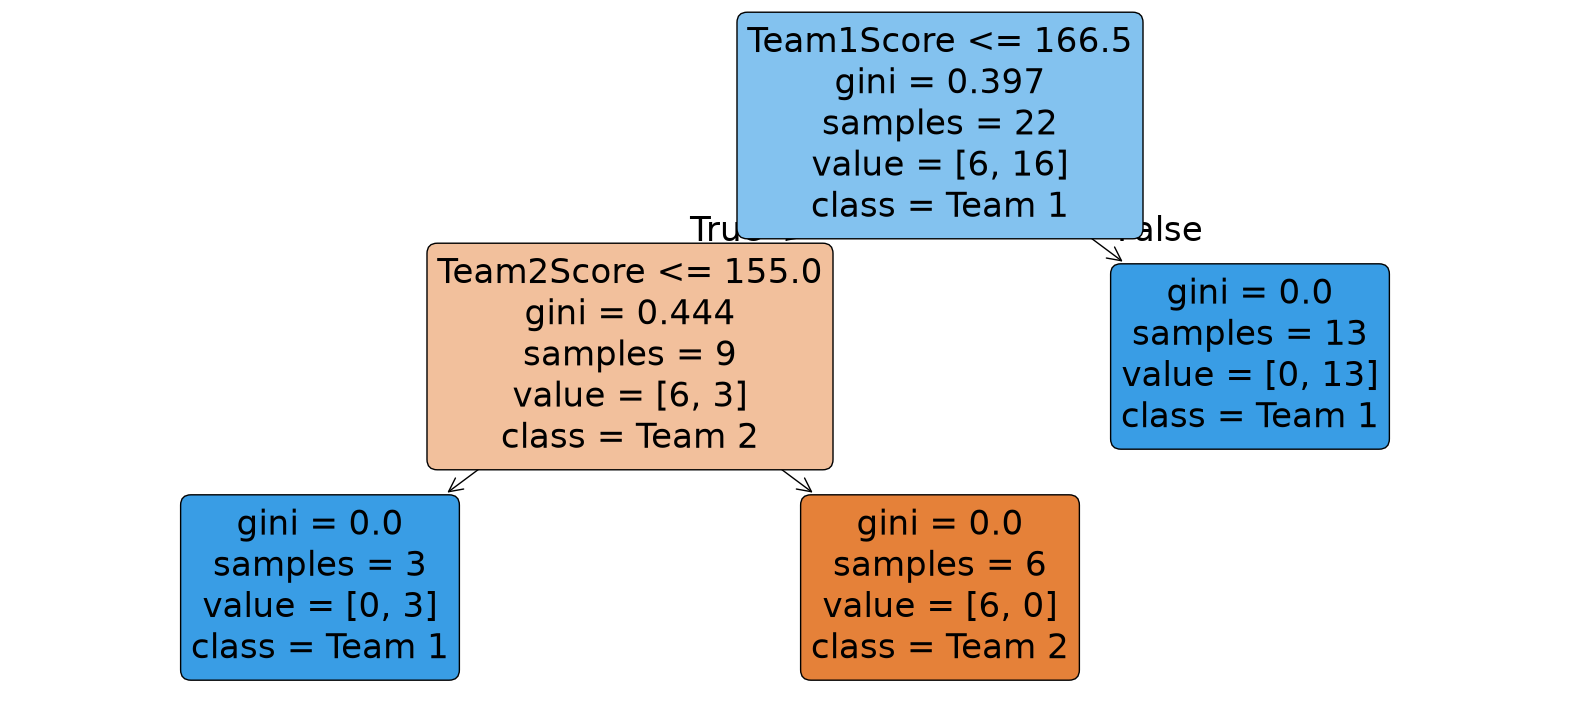

In [9]:
plt.figure(figsize=(20,9)); plot_tree(models['Decision Tree'],feature_names=X.columns,class_names=['Team 2','Team 1'],filled=True,rounded=True); plt.show()


,Feature,Importance
4,Team1Score,0.310366
5,Team2Score,0.199822
2,TossWinner,0.142819
7,Wickets,0.142117
0,Team1,0.091766
1,Team2,0.089932
3,TossDecision,0.023178
6,Overs,0.000000


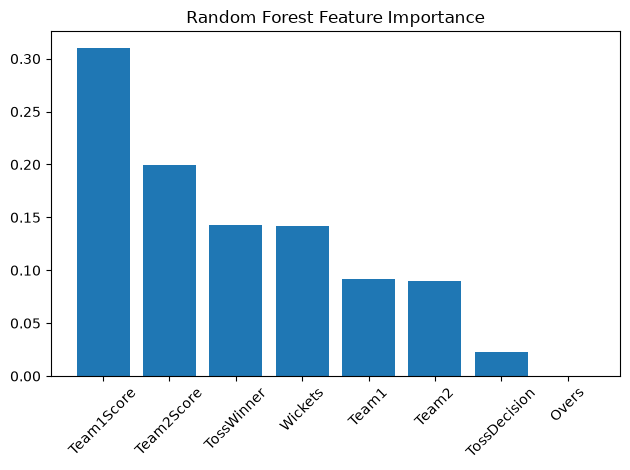

In [10]:
rf=models['Random Forest']; imp=pd.DataFrame({'Feature':X.columns,'Importance':rf.feature_importances_}).sort_values('Importance',ascending=False); display(imp)
plt.bar(imp['Feature'],imp['Importance']); plt.title('Random Forest Feature Importance'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


## 9. New Match Prediction

In [11]:
new_match=pd.DataFrame([{'Team1':'India','Team2':'Australia','TossWinner':'India','TossDecision':'Bat','Team1Score':185,'Team2Score':170,'Overs':20,'Wickets':5}])
new_encoded=new_match.copy()
for col in ['Team1','Team2','TossWinner','TossDecision']:
    new_encoded[col]=encoders[col].transform(new_encoded[col])
p=best_model.predict(new_encoded)[0]
print('Predicted Winner:','Team 1' if p==1 else 'Team 2')
if hasattr(best_model,'predict_proba'):
    prob=best_model.predict_proba(new_encoded)[0]
    print('Team 2 probability:',round(prob[0]*100,2),'%')
    print('Team 1 probability:',round(prob[1]*100,2),'%')


Predicted Winner: Team 1
Team 2 probability: 1.0 %
Team 1 probability: 99.0 %


In [13]:
import joblib
joblib.dump(best_model, "cricket_model.pkl")
joblib.dump(encoders, "encoders.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

print("Model saved!")

Model saved!


## 10. Conclusion

This project demonstrates dataset loading, inspection, missing-value checking, duplicate handling, descriptive statistics, Pandas operations, visualization, encoding, train/test split, scaling, Logistic Regression, KNN, Decision Tree, Random Forest, accuracy, confusion matrix, precision, recall, F1-score, feature importance and new-match prediction.